# PART III:  Error analysis MC method

In [5]:
import sys,os
import numpy as np
import scipy
from scipy.integrate import quad
from scipy.stats import kde
from scipy.stats import chi2 as spchi2
from scipy.optimize import minimize,leastsq
import matplotlib
import matplotlib.pyplot as py
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)  
%matplotlib inline  
%config InlineBackend.figure_format = 'retina'
from tools import tex,save, load,fill_between,plot_hist
from tools import EVENTS,VEC4
from iminuit import Minuit,describe, Struct
import numpy.linalg as LA 
from scipy.interpolate import interp1d
from scipy.optimize import fsolve,brentq,newton,fmin
from numpy.random import randn

# The signal + background

Get data

In [66]:
path='samples/sb.lhe.gz'
sb=EVENTS(path)
sb.D['m']=[]
for i in range(sb.nevents):
    particles=sb.EVENTS[i]
    for p in particles:
        if p['pid']==-13: mub=p['mom']
        elif p['pid']==13: mu=p['mom']
    z=mu+mub
    sb.D['m'].append((z*z)**0.5) 

construct observable

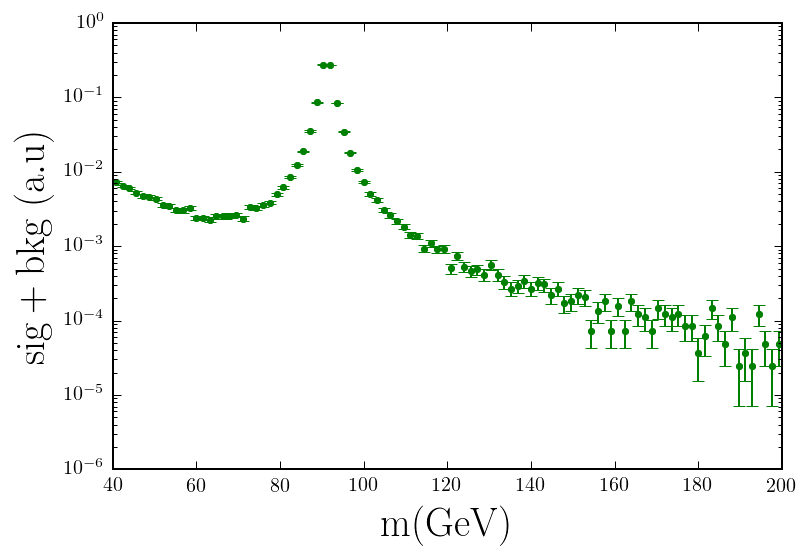

In [57]:
N,E=np.histogram(sb.D['m'],bins=100,range=(40,200))

M=0.5*(E[:-1]+E[1:])
NTOT=np.sum(N)
OBS=N/float(NTOT)
ERR=np.sqrt(N)/float(NTOT)

ax=py.subplot(111)
ax.errorbar(M,OBS,yerr=ERR,fmt='g.')
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

Compute MC fits

In [63]:
model_sig = lambda p,m: p[0]/((m**2-p[1]**2)**2+(p[2]*p[1])**2) 
model_bkg = lambda p,m: p[3]/m**(p[4]+4) 
model_sb  = lambda p,m: model_sig(p,m)+model_bkg(p,m)
res=lambda p,OBS: (OBS-model_sb(p,M))/ERR
p0=leastsq(res,[1,90,1,1,1],args=(OBS),full_output=1)[0]

nrep=10000
POPT=[]
REP=[]
CHI2=[]
for i in range(nrep):
    OBSk=OBS + randn(OBS.size)*ERR
    fit=leastsq(res,p0,args=(OBSk),full_output=1)
    resk=res(fit[0],OBSk)
    CHI2.append(np.dot(resk,resk)/(OBS.size-p0.size))
    POPT.append(fit[0])
    REP.append(OBSk)

/usr/lib/python2.7/site-packages/IPython/kernel/__main__.py:2: RuntimeWarning: divide by zero encountered in divide
  from IPython.kernel.zmq import kernelapp as app


$\chi^2$ profile

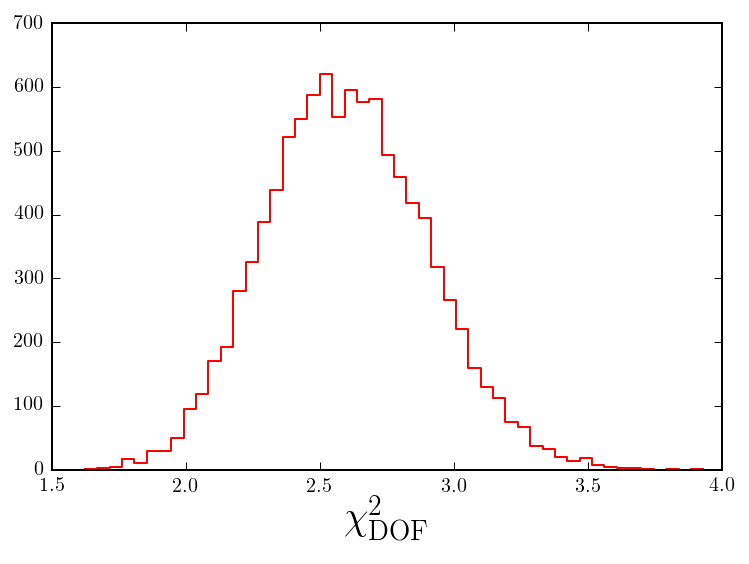

In [65]:
N,E=np.histogram(CHI2,bins=50)
ax=py.subplot(111)
plot_hist(ax,'r',E,N,symbol='-')
ax.set_xlabel(tex('\chi^2_{DOF}'),size=20)

plot results

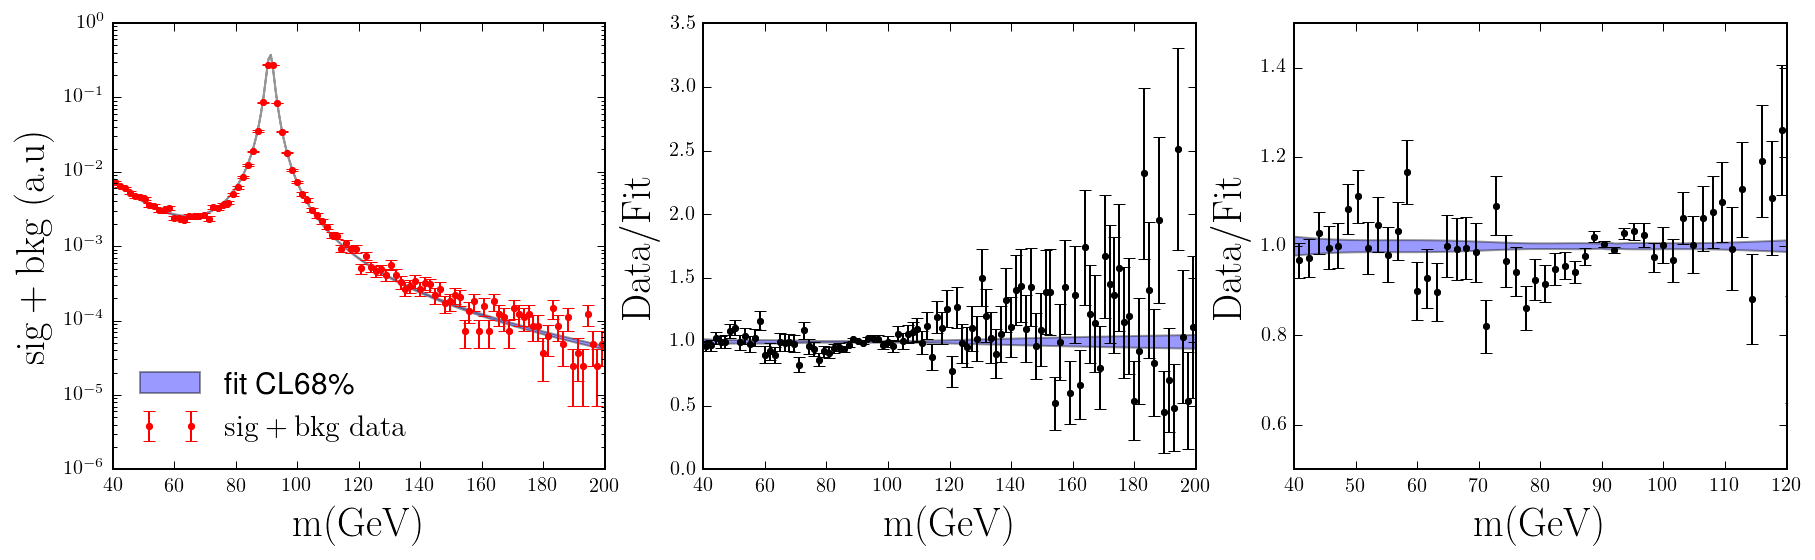

In [53]:
M0=np.linspace(40,200,200)
OBSK=np.zeros((len(POPT),len(M0)))
for k in range(nrep): OBSK[k]=model_sb(POPT[k],M0)
OBS0=model_sb(p0,M0)
std=np.std(OBSK,axis=0)
OBSMAX=OBS0+std
OBSMIN=OBS0-std

py.figure(figsize=(5*3,4*1))

ax=py.subplot(131)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('sig+bkg~data'))
fill_between(M0,y1=OBSMIN,y2=OBSMAX, ax=ax, facecolor='b',alpha=0.4,label='fit~CL68\%')
ax.semilogy()
ax.legend(fontsize=15,frameon=0,loc=3)
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)

ax=py.subplot(132)
fill_between(M0,y1=OBSMIN/OBS0,y2=OBSMAX/OBS0, ax=ax, facecolor='b',alpha=0.4,label='fit~CL68\%')
ax.errorbar(M,OBS/model_sb(p0,M),yerr=ERR/model_sb(p0,M),fmt='k.')
ax.set_ylabel(tex(r'Data/Fit'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)

ax=py.subplot(133)
fill_between(M0,y1=OBSMIN/OBS0,y2=OBSMAX/OBS0, ax=ax, facecolor='b',alpha=0.4,label='fit~CL68\%')
ax.errorbar(M,OBS/model_sb(p0,M),yerr=ERR/model_sb(p0,M),fmt='k.')
ax.set_xlim(40,120)
ax.set_ylim(0.5,1.5);
ax.set_ylabel(tex(r'Data/Fit'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)